<a href="https://colab.research.google.com/github/sadot04/Inteligencia_artificial/blob/main/OPENCV3_13_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [89]:
#importamos las librerias necesarias
import cv2 #Importamos OpenCV para procesamiento de imagenes
import numpy as np #Importamos numpy para manejarlo de arrays
import matplotlib.pyplot as plt #Importamos matplotlib para visualizacion
from google.colab.patches import cv2_imshow #Importamos funcion para mostrar imagenes en colab

# Cargar una imagen de ejemplo
from urllib.request import urlopen

# URL de una imagen de ejemplo
url = 'https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg'
# Abrimos la URL y leemos los bytes de la imagen
resp = urlopen(url)
# Convertimos los bytes a un array de numpy
image = np.asarray(bytearray(resp.read()), dtype="uint8")
# Decodificamos el array como una imagen usando OpneCV
image = cv2.imdecode(image, cv2.IMREAD_COLOR)
# OpenCV carga las imagenes en formato BGR, lo conertimos a RGB para visuakuzacion correcta
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


In [90]:
#1. Suavizado de imagen con filtro gaussiano
# Aplicamos un filtro gaussiano para suavisar la imagen (kernel de 5x5)
blurred_image = cv2.GaussianBlur(image_rgb, (5, 5), 0) # (5,5) es el tamaño del kernel, 0 es la desviacion estandar

# 2. Filtro de desnfoque medio
# Aplicamos un filtro de promedio para suavisar la imagen (kernel de 5x5)
average_blur = cv2.blur(image_rgb, (5,5))

# 3. Filtro de desenfoque mediano
# Aplicamos un filtro de mediana para reducir el ruido (tamaño de ventana 5)
median_blur = cv2.medianBlur(image_rgb, 5) #5 es el tamaño de la venta

# 4. Filtro de desenfoque bilateral
# este filtro preserva los bordes mientras suavisa las áreas planas
bilateral_blur = cv2.bilateralFilter(image_rgb, 9, 75, 75) #9 es el diametro del vecindario, 75 son sigma oclor y espaciado

In [91]:
#5 Ajuste de brillo y contraste
#Ajustamos brillo y contraste usando transformacion lineal alpha*img + beta
alpha =1.5 #Factor de contraste (>1 aumenta, < 1 disminuye)
beta = 30 #Factor de brillo(>0 aumenta, <0 disminuye)
adjusted = cv2.convertScaleAbs(image_rgb, alpha=alpha,beta =beta) #Aplicamos la transformacion


In [92]:
#6 Ecualizacion de histograma (en escala de grises)
#Convertimos a escala de grises
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
#Aplicamos ecualizacion de histograma para mejorar el contraste
equalized = cv2.equalizeHist(gray_image)

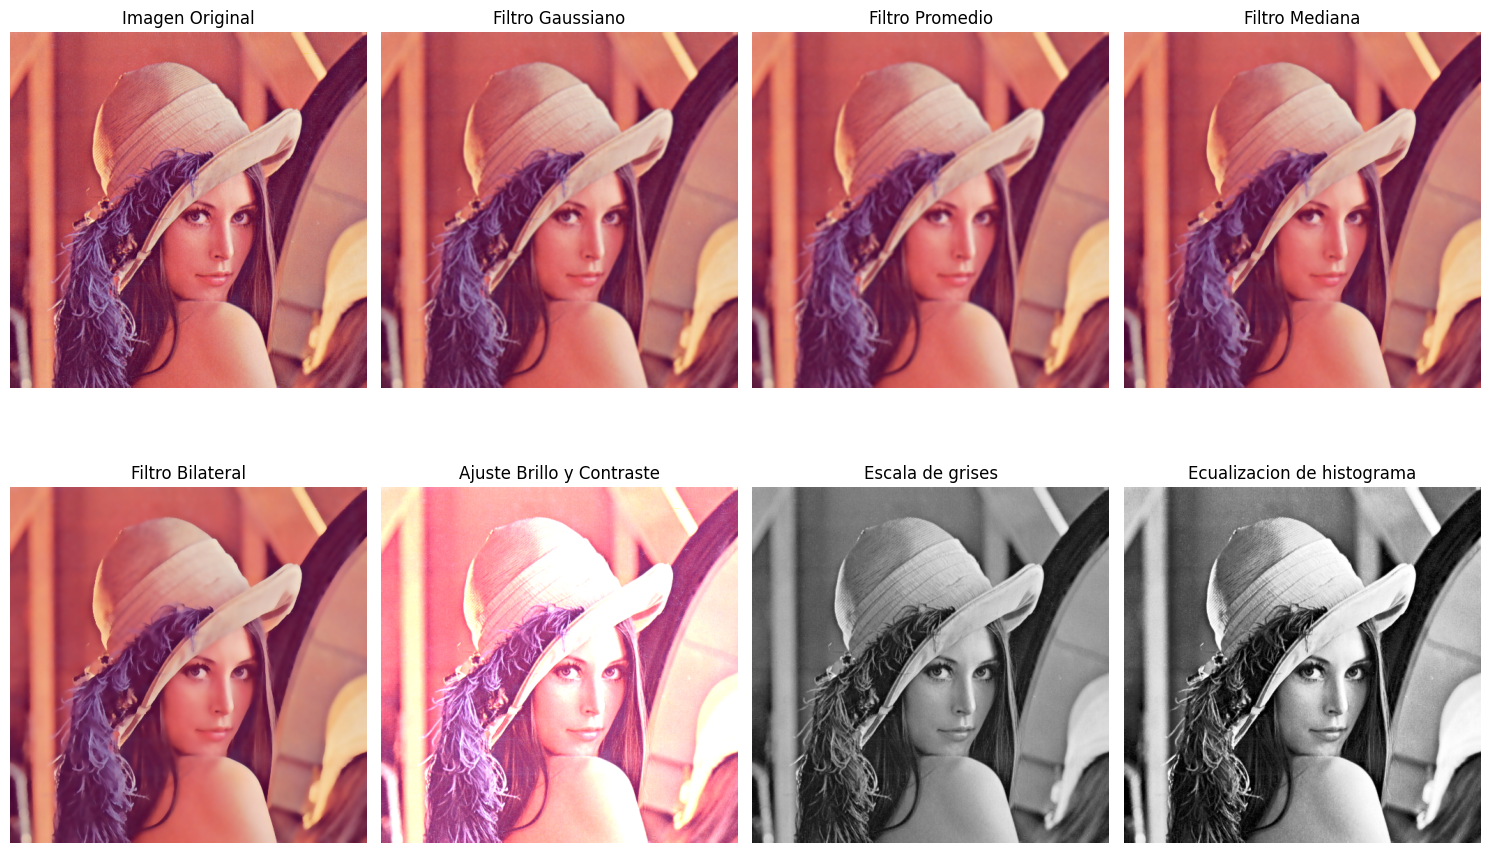

/tmp/ipython-input-489120955.py:62: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(gray_image.ravel(), 256, [0, 256]) #Calculamos y mostramos el histograma
/tmp/ipython-input-489120955.py:69: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(equalized.ravel(), 256, [0, 256]) #Calculamos y mostramos el histograma


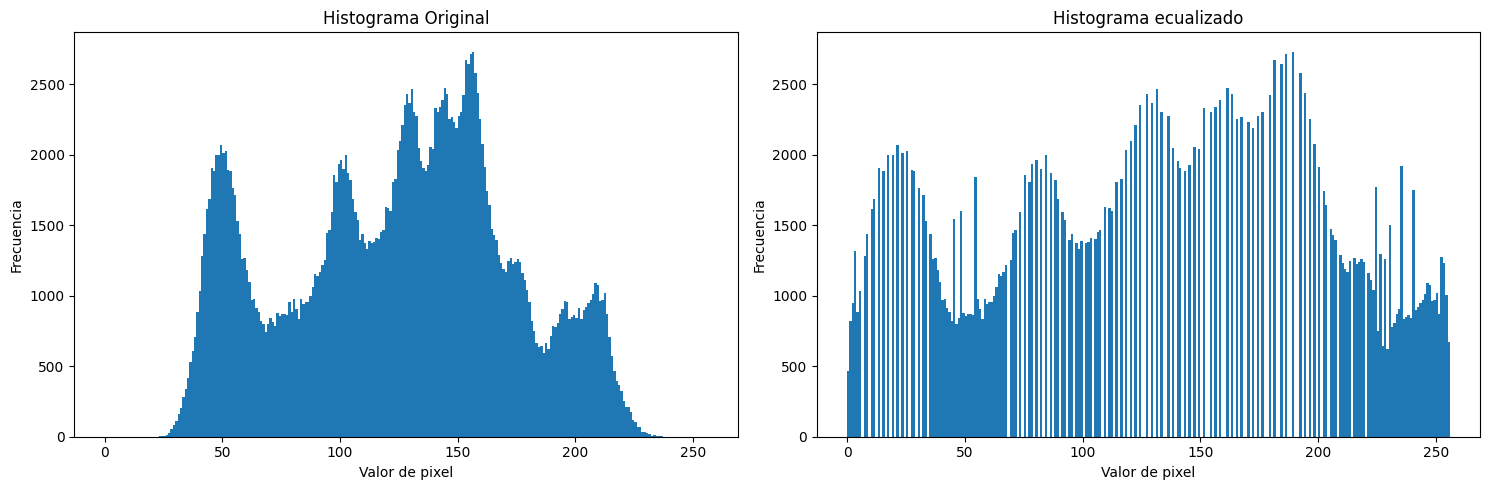

In [93]:
#Visualizacion de todos los filtros
plt.figure(figsize=(15,10)) #Creamos una figura con tamano especifico

#Imagen original
plt.subplot(2,4,1) #Creamos un subplot en la posicion 1
plt.title("Imagen Original") #Anadimos un titulo
plt.imshow(image_rgb) #Mostramos la imagen original
plt.axis('off') #Ocultamos los ejes

#Imagen con filtro de gaussiano
plt.subplot(2,4,2) #Creamos un subplot en la posicion 2
plt.title('Filtro Gaussiano') #Anadimos un titulo
plt.imshow(blurred_image) #Mostramos la imagen con filtro gaussiano
plt.axis('off') #Ocultamos los ejes

#Imagen con filtro promedio
plt.subplot(2,4,3) #Creamos un subplot en la posicion 3
plt.title('Filtro Promedio') #Anadimos un titulo
plt.imshow(average_blur) #Mostramos la imagen con filtro de promedio
plt.axis('off') #Ocultamos los ejes

#Imagen con filtro de mediana
plt.subplot(2,4,4) #Creamos un subplot en la posicion 4
plt.title('Filtro Mediana') #Anadimos un titulo
plt.imshow(median_blur) #Mostramos la imagen con filtro de mediana
plt.axis('off') #Ocultamos los ejes

#Imagen con filtro bilateral
plt.subplot(2,4,5) #Creamos un subplot en la posicion 5
plt.title('Filtro Bilateral') #Anadimos un titulo
plt.imshow(bilateral_blur) #Mostramos la imagen con filtro bilateral
plt.axis('off') #Ocultamos los ejes

#Imagen con ajuste de brillo y contraste
plt.subplot(2,4,6) #Creamos un subplot en la posicion 6
plt.title("Ajuste Brillo y Contraste") #Anadimos un titulo
plt.imshow(adjusted) #Mostramos la imagen con ajuste de brillo y contraste
plt.axis('off') #Ocultamos los ejes

#Imagen original en escala de grises
plt.subplot(2,4,7) #Creamos un subplot en la posicion 7
plt.title("Escala de grises") #Anadimos un titulo
plt.imshow(gray_image, cmap='gray') #Mostramos la imagen en escala de grises
plt.axis('off') #Ocultamos los ejes

#Imagen con ecualizacion de histograma
plt.subplot(2,4,8) #Creamos un subplot en la posicion 8
plt.title("Ecualizacion de histograma") #Anadimos un titulo
plt.imshow(equalized, cmap='gray') # Mostramos la imagen con encualizacion de histograma
plt.axis('off') #Ocultamos los ejes

plt.tight_layout() #Ajustamos e layout para que no se superpongan los titulos
plt.show() #Mostramos la figura completa

#Visualizacion de histogramas
plt.figure(figsize=(15,5)) #Creamos una figura con tamanio especifico


#Histograma de la imagen original en escala de grises
plt.subplot(1, 2, 1) #Creamos un subplot en la posicion 1
plt.title('Histograma Original') #Aniadimos en titulo
plt.hist(gray_image.ravel(), 256, [0, 256]) #Calculamos y mostramos el histograma
plt.xlabel('Valor de pixel') #Etiqueta eje X
plt.ylabel('Frecuencia') # Etiqueta eje Y

#Histograma de la imagen ecualizada
plt.subplot(1, 2, 2) #Creamos un subplot en la posicion 2
plt.title('Histograma ecualizado') #Aniadimos un titulo
plt.hist(equalized.ravel(), 256, [0, 256]) #Calculamos y mostramos el histograma
plt.xlabel('Valor de pixel') #Etiqueta X
plt.ylabel('Frecuencia') #Etiqueta eje X



plt.tight_layout() # Ajustamos el layout para que no se superpongan los titulos
plt.show() # Mostramos la figura


In [94]:
# 1. Filtro Laplaciano
# Resalta los bordes y detalles finos en la imagen
laplacian_filter = cv2.Laplacian(image_rgb, cv2.CV_64F)

# 2. Filtro de Gabor
# Detecta texturas y patrones en una orientación específica (útil para rostros o huellas)
ksize = 31  # tamaño del kernel
sigma = 4.0  # desviación estándar de la gaussiana
theta = np.pi / 1  # orientación del filtro (45°)
lamda = 10.0  # longitud de onda
gamma = 0.5  # relación de aspecto
phi = 0  # desplazamiento de fase
gabor_kernel = cv2.getGaborKernel((ksize, ksize), sigma, theta, lamda, gamma, phi, ktype=cv2.CV_32F)
gabor_filter = cv2.filter2D(image_rgb, cv2.CV_8UC3, gabor_kernel)

# 3. Ecualización de histograma
# Mejora el contraste general de la imagen expandiendo el rango dinámico
gray_image = cv2.cvtColor(image_rgb, cv2.COLOR_BGR2GRAY)
equalized_filter = cv2.equalizeHist(gray_image)

# 4. Filtro morfológico (apertura)
# Elimina pequeños puntos de ruido y suaviza los bordes
kernel = np.ones((5, 5), np.uint8)
morph_open_filter = cv2.morphologyEx(image_rgb, cv2.MORPH_OPEN, kernel)


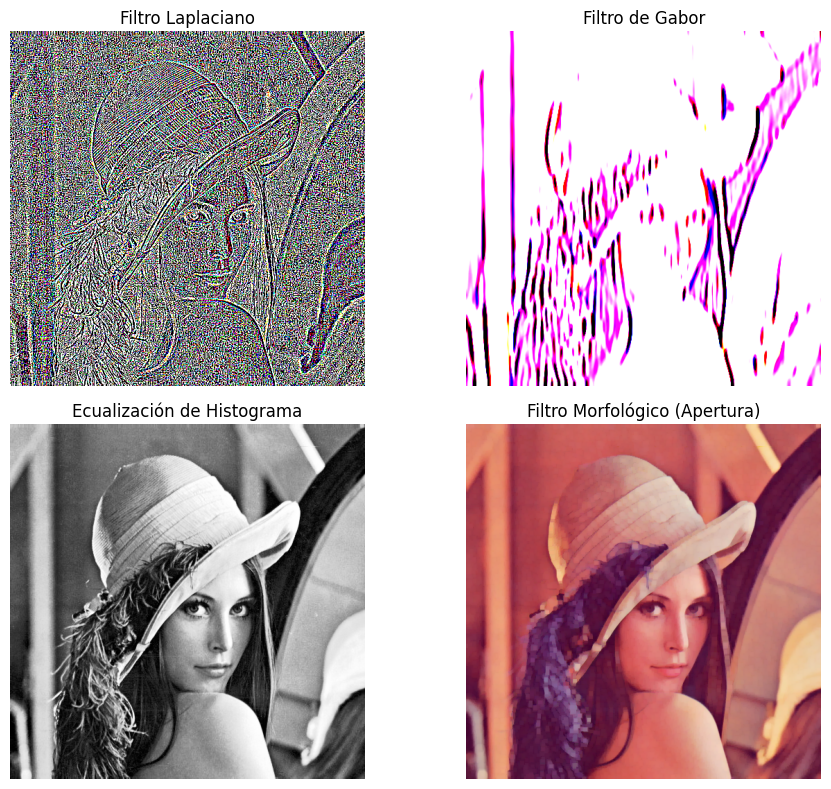

In [95]:
plt.figure(figsize=(10, 8))

# 1. Filtro Laplaciano
plt.subplot(2, 2, 1)
plt.title('Filtro Laplaciano')
plt.imshow(laplacian_filter, cmap='gray')
plt.axis('off')

# 2. Filtro de Gabor
plt.subplot(2, 2, 2)
plt.title('Filtro de Gabor')
plt.imshow(gabor_filter, cmap='gray')
plt.axis('off')

# 3. Ecualización de Histograma
plt.subplot(2, 2, 3)
plt.title('Ecualización de Histograma')
plt.imshow(equalized_filter, cmap='gray')
plt.axis('off')

# 4. Filtro Morfológico (Apertura)
plt.subplot(2, 2, 4)
plt.title('Filtro Morfológico (Apertura)')
plt.imshow(morph_open_filter, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()
